# EDA

Цель исследования - подготовить данные для прогноза количества гостей ресторана на следующие 7 дней. Ноутбук последовательно рассматривает качество исходных транзакций, формирует дневной временной ряд, проверяет ограничения целевой переменной и создаёт признаки без утечки данных.

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import holidays

## Загрузка данных и первичный анализ

Сначала изучим данные, проанализируем пропуски, дубликаты, типы признаков

In [2]:
df = pd.read_csv('../data/raw/restaurant_sales_data.csv')
display(df)

,Order ID,Customer ID,Category,Item,Price,Quantity,Order Total,Order Date,Payment Method
0,ORD_705844,CUST_092,Side Dishes,Side Salad,3.0,1.0,3.0,2023-12-21,Credit Card
1,ORD_338528,CUST_021,Side Dishes,Mashed Potatoes,4.0,3.0,12.0,2023-05-19,Digital Wallet
2,ORD_443849,CUST_029,Main Dishes,Grilled Chicken,15.0,4.0,60.0,2023-09-27,Credit Card
3,ORD_630508,CUST_075,Drinks,NaN,NaN,2.0,5.0,2022-08-09,Credit Card
4,ORD_648269,CUST_031,Main Dishes,Pasta Alfredo,12.0,4.0,48.0,2022-05-15,Cash
...,...,...,...,...,...,...,...,...,...
17529,ORD_320102,CUST_021,Drinks,NaN,NaN,4.0,4.0,2023-12-23,Cash
17530,ORD_974128,CUST_069,Desserts,Ice Cream,5.0,3.0,15.0,2023-12-18,Cash
17531,ORD_108324,CUST_050,Desserts,Ice Cream,5.0,4.0,20.0,2022-05-20,Digital Wallet
17532,ORD_612647,CUST_073,Side Dishes,Mashed Potatoes,4.0,2.0,8.0,2022-01-27,Digital Wallet


In [3]:
print(f'Размер датасета: {df.shape}\n')
df.info()


Размер датасета: (17534, 9)

<class 'pandas.DataFrame'>
RangeIndex: 17534 entries, 0 to 17533
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        17534 non-null  str    
 1   Customer ID     17534 non-null  str    
 2   Category        17534 non-null  str    
 3   Item            15776 non-null  str    
 4   Price           16658 non-null  float64
 5   Quantity        17104 non-null  float64
 6   Order Total     17104 non-null  float64
 7   Order Date      17534 non-null  str    
 8   Payment Method  16452 non-null  str    
dtypes: float64(3), str(6)
memory usage: 1.2 MB


In [4]:
df.describe()

,Price,Quantity,Order Total
count,16658.000000,17104.000000,17104.000000
mean,6.586325,3.014149,19.914494
std,4.834652,1.414598,18.732549
min,1.000000,1.000000,1.000000
25%,3.000000,2.000000,7.500000
50%,5.000000,3.000000,15.000000
75%,7.000000,4.000000,25.000000
max,20.000000,5.000000,100.000000


In [5]:
print("Количество полных дубликатов:", df.duplicated().sum())

df.isnull().sum() # покажет где именно и сколько пропущенных значений

Количество полных дубликатов: 0


Order ID             0
Customer ID          0
Category             0
Item              1758
Price              876
Quantity           430
Order Total        430
Order Date           0
Payment Method    1082
dtype: int64

### Промежуточный вывод

Датасет содержит транзакционные данные ресторана. Одна строка соответствует заказу, поэтому перед моделированием данные необходимо агрегировать до дневного уровня.

В датасете есть ряд проблем:
- наличие прпущенных значение. простым удалением мы рискуем потерять важные значения, поэтому необходимо обработать пропуски по-другому
- наличие бесполезных (для задачи) признаков, которые в конце можно удалить

# Подготовка датасета

In [6]:
df_clean = df.copy()

In [7]:
df_clean['date'] = pd.to_datetime(df_clean['Order Date'])
df_clean = df_clean.drop(columns='Order Date')
df_clean.dtypes


Order ID                     str
Customer ID                  str
Category                     str
Item                         str
Price                    float64
Quantity                 float64
Order Total              float64
Payment Method               str
date              datetime64[us]
dtype: object

Попробуем восстановить значения price, если известные quantity и order_total

In [8]:
columns = ['Price', 'Quantity', 'Order Total']

empty_rows = df_clean[df_clean['Price'].isna() & df_clean['Quantity'].notna() & df_clean['Order Total'].notna()]

display(empty_rows.head())

,Order ID,Customer ID,Category,Item,Price,Quantity,Order Total,Payment Method,date
3,ORD_630508,CUST_075,Drinks,NaN,NaN,2.0,5.0,Credit Card,2022-08-09
83,ORD_167858,CUST_056,Side Dishes,NaN,NaN,5.0,25.0,Cash,2022-04-01
112,ORD_289733,CUST_057,Drinks,NaN,NaN,5.0,5.0,NaN,2022-01-05
122,ORD_363522,CUST_070,Starters,NaN,NaN,1.0,8.0,Credit Card,2023-05-07
146,ORD_499199,CUST_079,Desserts,NaN,NaN,5.0,25.0,Digital Wallet,2022-02-12


In [9]:
recover_price = (
    df_clean['Price'].isna()
    & df_clean['Order Total'].notna()
    & df_clean['Quantity'].notna()
    & df_clean['Quantity'].ne(0)
    & df_clean['Order Total']
)

print(f'Можно однозначно восстановить:, {recover_price.sum()}')

df_clean['Price'] = df_clean['Price'].fillna(
    df_clean['Order Total'] / df_clean['Quantity']
)

Можно однозначно восстановить:, 446


В части строк одновременно отсутствуют Price, Quantity и Order Total. Однозначно восстановить финансовые показатели для таких записей невозможно, но и удалять на этом этапе я бы не стал. Customer ID остаётся доступным, поэтому запись всё ещё содержит информацию о факте посещения. Поэтому флаг индикации отсутсвия значения

In [10]:
df_clean['has_missing_sales'] = (df_clean['Price'].isna() | df_clean['Quantity'].isna() | df_clean['Order Total'].isna()).astype(int)
print(f'Строк с неполными финансовыми данными: {df_clean["has_missing_sales"].sum()}')

Строк с неполными финансовыми данными: 430


Такие признаки как category, item и payment_method не используются для определения количества гостей, поэтому мы можем их удалить

In [11]:
df_clean = df_clean.drop(columns= ['Category', 'Item', 'Payment Method'])
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 17534 entries, 0 to 17533
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order ID           17534 non-null  str           
 1   Customer ID        17534 non-null  str           
 2   Price              17104 non-null  float64       
 3   Quantity           17104 non-null  float64       
 4   Order Total        17104 non-null  float64       
 5   date               17534 non-null  datetime64[us]
 6   has_missing_sales  17534 non-null  int64         
dtypes: datetime64[us](1), float64(3), int64(1), str(2)
memory usage: 959.0 KB


## Промежуточный вывод

Пропуски обработаны с учетом их природы. Где есть возможность я восстановил данные в явном виде, где возможности нет, то добавил флаг, который можно учитывать при дальнейшей агрегации данных.

# Формирование дневного датасета

Исходные данные представлены на уровне заказов, но по заданию нужно прогноз на уровне дней

В качестве количества гостей будем использовать количество уникальных гостей из customer_id.
Ограничение - поскольку датасет не содержит фактического количества посетителей за столом, то интерпретируем один уникальные id гостя как один гость.

In [12]:
daily = (
    df_clean.groupby(df_clean['date'].dt.normalize())
    .agg(
        guests=('Customer ID', 'nunique'),
        orders=('Order ID', 'nunique'),
        quantity=('Quantity', 'sum'),
        revenue=('Order Total', 'sum'),
        mean_price=('Price', 'mean'),
        missing_sales_count=('has_missing_sales', 'sum')
    )
    .reset_index()
    .sort_values('date')
    .reset_index(drop=True)
)

daily['missing_ratio'] = daily['missing_sales_count'] / daily['orders']
daily.head()

,date,guests,orders,quantity,revenue,mean_price,missing_sales_count,missing_ratio
0,2022-01-01,25,28,90.0,640.0,7.000000,0,0.000000
1,2022-01-02,24,26,76.0,479.0,6.653846,0,0.000000
2,2022-01-03,22,24,67.0,317.0,5.478261,1,0.041667
3,2022-01-04,25,28,94.0,628.0,7.321429,0,0.000000
4,2022-01-05,21,23,62.0,447.5,7.309524,2,0.086957


missing_sales_count и missing_ratio позволяет оценить дни, для которых агрегированные значения revenue и quantity занижены из-за пропусков

Далее необходимо убедится, что у нас нет пропусков в днях и временной ряд идет гладко

In [13]:
dates = pd.date_range(
    start=daily['date'].min(),
    end=daily['date'].max(),
    freq='D'
)

missing_dates = dates.difference(daily['date'])

print(f'Пропущено дней: {len(missing_dates)}')

Пропущено дней: 0


Пропущенных значений нет, временной ряд имеет ежедневное частоту

Проверим можно ли использовать информацию по возвращающимся клиентам. Потенциально может оказаться полезной информация о том, как часто и в какой период гости возвращаютс в ресторан. Клиент считается вернувшимся, если уже встречался в прошлом.

In [14]:
first_visit = df_clean.groupby('Customer ID')['date'].min().dt.normalize().rename('first_visit')

new_guests_by_day = first_visit.value_counts().rename('new_guests')
customer_stats = daily[['date', 'guests']].copy()
customer_stats['new_guests'] = (
    customer_stats['date'].map(new_guests_by_day).fillna(0).astype(int)
)
customer_stats['returning_guests'] = (
    customer_stats['guests'] - customer_stats['new_guests']
)
customer_stats['returning_share'] = (
    customer_stats['returning_guests'] / customer_stats['guests']
)

print(f'Уникальных клиентов: {df_clean["Customer ID"].nunique()}')
print(f'Когда появился крайний уникальный гость: {first_visit.max().date()}')
print(f'Дней когда клиенты уже встречались: {(customer_stats["returning_share"] == 1).sum()} из {len(customer_stats)}')


Уникальных клиентов: 100
Когда появился крайний уникальный гость: 2022-01-29
Дней когда клиенты уже встречались: 715 из 730


## Промежуточный вывод

Подготовили дневной датасет. Убедился что временной лаг без пропусков и дни идут строго друг за другом, а также обнаружил, что странная ситуация по уникальынм клиентам. Единственная интерпретация (кроме того, что датасет синтезирован искусственно) это какое-то закрытое заведение, куда может попасть человек, который по приглашению. В общем ситуация странная, но в рамках тестового можно принять как ограничение :)

# Исследовательский анализ посещаемости

Рассмотрим изменение дневной количества гостей во времени. Это позволяет оценить динамику, тренд и периоды аномальной посещаемости

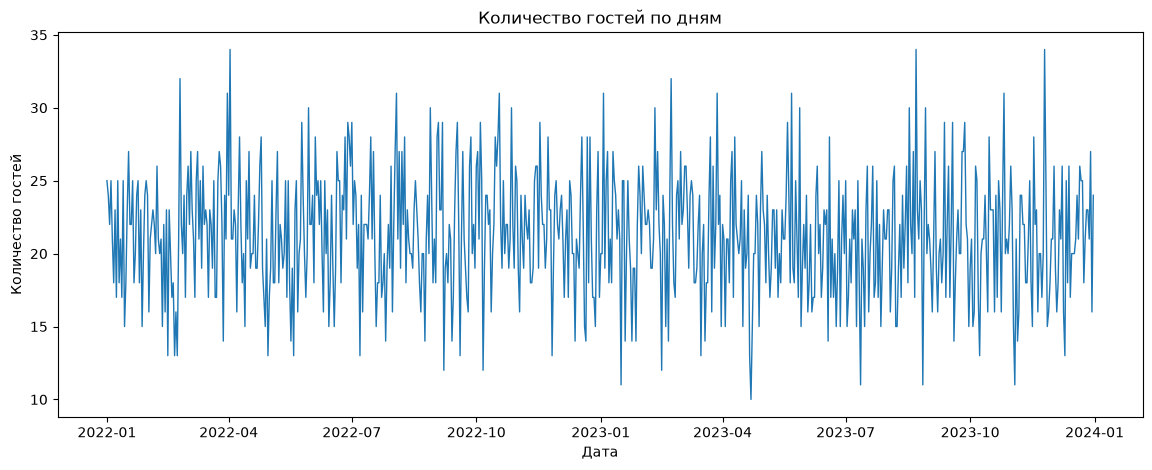

In [15]:
plt.figure(figsize=(14, 5))
plt.plot(daily['date'], daily['guests'], linewidth=1)
plt.title('Количество гостей по дням')
plt.xlabel('Дата')
plt.ylabel('Количество гостей')
plt.show()

### Вывод

Дневная посещаемость заметно колеблется, однако резких структурных изменений визуально не наблюдается. Для более точной оценки долгосрочного изменения уровня ряда ниже дополнительно рассмотрим сглаженную и месячную динамику.


## Недельная сезонность

Сравним среднее количество гостей по дням недели. Выраженные различия между днями могут обосновать использование day_of_week и недельных лагов в модели.

,mean_guests
ПН,21.45
ВТ,21.20
СР,21.05
ЧТ,21.33
ПТ,21.71
СБ,21.28
ВСКР,21.03


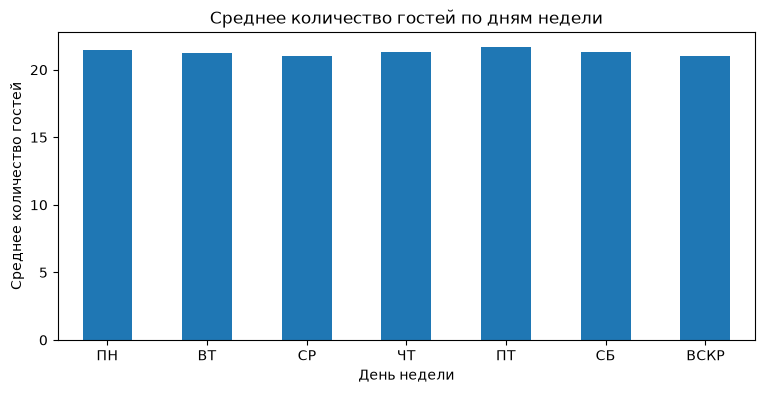

In [16]:
day_names = ['ПН','ВТ','СР','ЧТ','ПТ','СБ','ВСКР']
weekly = daily.groupby(daily['date'].dt.dayofweek)['guests'].mean()
weekly.index = day_names

display(weekly.rename('mean_guests').round(2).to_frame())
weekly.plot(kind='bar', figsize=(9, 4), rot=0)
plt.title('Среднее количество гостей по дням недели')
plt.xlabel('День недели')
plt.ylabel('Среднее количество гостей')
plt.show()


### Промежуточный вывод

Средняя посещаемость по дням недели различается незначительно. Поэтому календарный признак day_of_week сохраняется для последующей проверки его полезности моделью.

## Сезонность по месяцам

Проверим, меняется ли средний уровень посещаемости в зависимости от месяца. Это позволяет оценить наличие более долгосрочной календарной сезонности.

,mean_guests
Янв,21.40
Фев,20.86
Мар,22.13
Апр,20.93
Май,21.10
Июн,21.28
Июл,20.40
Авг,21.92
Сен,21.33
Окт,22.11


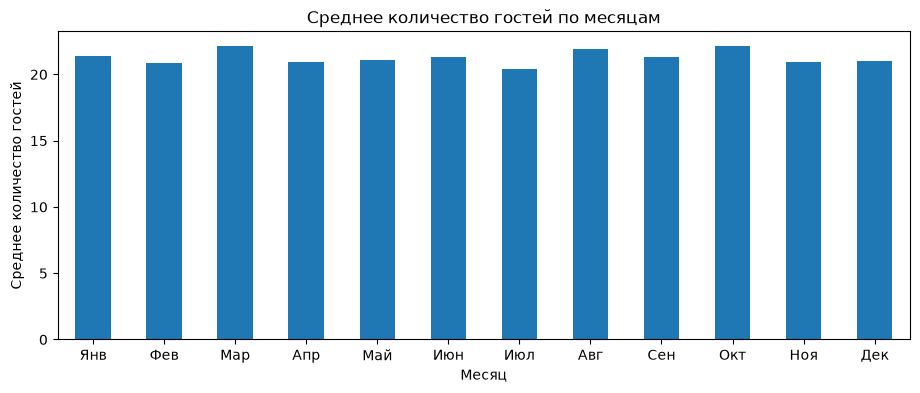

In [17]:
month_names = [
    'Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн',
    'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек'
]
monthly = daily.groupby(daily["date"].dt.month)["guests"].mean()
monthly.index = month_names

display(monthly.rename('mean_guests').round(2).to_frame())
monthly.plot(kind='bar', figsize=(11, 4), rot=0)
plt.title('Среднее количество гостей по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Среднее количество гостей')
plt.show()


### Промежуточный вывод

Средняя посещаемость по месяцам различается незначительно. Поэтому календарный признак month сохраняется для последующей проверки его полезности моделью.

## Оценим распределение целевой переменной

Исследуем распределение guests и потенциальные экстремальные значения. 

/tmp/ipykernel_26318/3421240086.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(daily['guests'], vert=False)


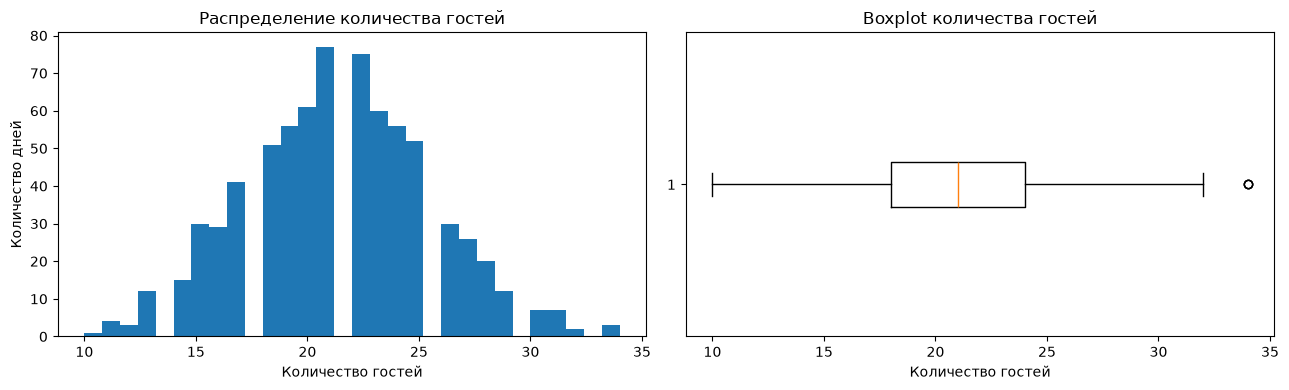

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(daily['guests'], bins=30)
axes[0].set_title('Распределение количества гостей')
axes[0].set_xlabel('Количество гостей')
axes[0].set_ylabel('Количество дней')

axes[1].boxplot(daily['guests'], vert=False)
axes[1].set_title('Boxplot количества гостей')
axes[1].set_xlabel('Количество гостей')
plt.tight_layout()
plt.show()


## Анализ потенциальных выбросов

Используяется межквартальный размах. Значения за границами интервала рассматриваются только как кандидаты на выбросы. Для временного ряда ресторана экстремальная посещаемость может быть реальным проявлением спроса (праздники например).

In [19]:
q1 = daily['guests'].quantile(0.25)
q3 = daily['guests'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = daily.loc[
    (daily['guests'] < lower_bound) | (daily['guests'] > upper_bound),
    ['date', 'guests', 'orders', 'quantity', 'revenue', 'mean_price', 'missing_ratio'],
]

print(f'Границы IQR: [{lower_bound:.1f}, {upper_bound:.1f}]')
print(f'Количество потенциальных выбросов: {len(outliers)}')
display(outliers)


Границы IQR: [9.0, 33.0]
Количество потенциальных выбросов: 3


,date,guests,orders,quantity,revenue,mean_price,missing_ratio
91,2022-04-02,34,40,109.0,739.5,6.812500,0.00000
598,2023-08-22,34,40,125.0,864.5,6.750000,0.00000
693,2023-11-25,34,42,130.0,999.5,7.634146,0.02381


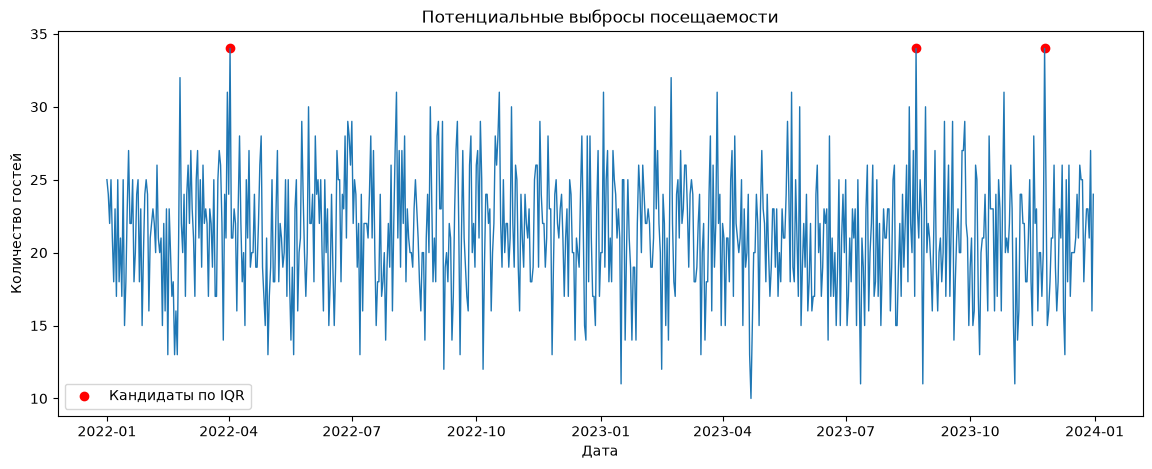

In [20]:
plt.figure(figsize=(14, 5))
plt.plot(daily['date'], daily['guests'], linewidth=1)
plt.scatter(outliers['date'], outliers['guests'], color='red', label='Кандидаты по IQR')
plt.title('Потенциальные выбросы посещаемости')
plt.xlabel('Дата')
plt.ylabel('Количество гостей')
plt.legend()
plt.show()


### Промежуточный вывод

Метод IQR выделил несколько потенциально необычных дней. Однако высокие значения guests сопровождаются повышенными orders, quantity и revenue.

Таким образом, явных признаков технической ошибки в этих наблюдениях не обнаружено. Потенциальные выбросы сохраняются в данных, поскольку они могут отражать реальные колебания спроса.

# Анализ календарных эффектов

Для исследовательского анализа создадим отдельную таблицу с календарными индикаторами. В основной таблице модельные признаки будут сформированы только после завершения EDA.

## Праздничные дни

Проверим, отличается ли средняя посещаемость в американские праздничные дни от обычных дней. Праздники определяются с помощью holidays.US() (поскольку в датасете в основном американская еда, то рынок для датасета именно там)

,count,mean
is_holiday,,
0,704,21.31
1,26,20.77


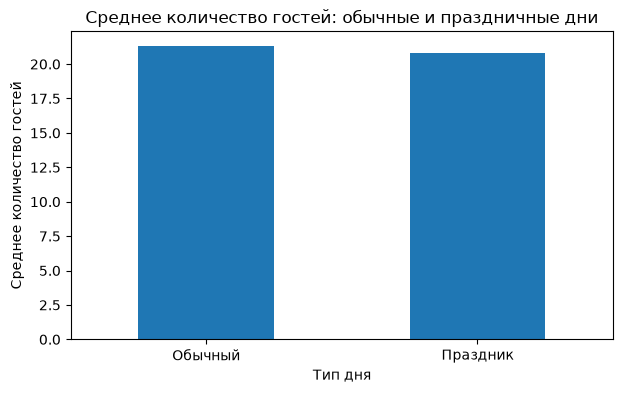

Разница: -2.5%


In [21]:
calendar_eda = daily[['date', 'guests']].copy()

if holidays is not None:
    holiday_dates = set(
        holidays.US(
            years=range(daily['date'].dt.year.min(), daily['date'].dt.year.max() + 1)
        ).keys()
    )
else:
    federal_calendar = USFederalHolidayCalendar()
    holiday_dates = set(
        federal_calendar.holidays(
            start=daily['date'].min(),
            end=daily['date'].max(),
        ).date
    )

calendar_eda['is_holiday'] = calendar_eda['date'].dt.date.map(
    lambda date: int(date in holiday_dates)
)
calendar_eda['is_weekend'] = calendar_eda['date'].dt.dayofweek.isin([5, 6]).astype(int)

holiday_stats = calendar_eda.groupby('is_holiday')['guests'].agg(['count', 'mean'])
display(holiday_stats.round(2))

holiday_stats['mean'].plot(kind='bar', figsize=(7, 4), rot=0)
plt.title('Среднее количество гостей: обычные и праздничные дни')
plt.xlabel('Тип дня')
plt.ylabel('Среднее количество гостей')
plt.xticks([0, 1], ['Обычный', 'Праздник'])
plt.show()

normal_mean = holiday_stats.loc[0, 'mean']
holiday_mean = holiday_stats.loc[1, 'mean']
holiday_difference = (holiday_mean / normal_mean - 1) * 100
print(f'Разница: {holiday_difference:.1f}%')


,count,mean
is_weekend,,
0,520,21.35
1,210,21.15


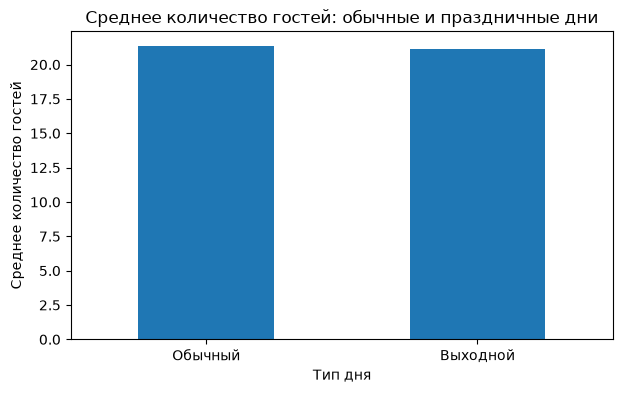

Разница: -0.9%


In [22]:
weekend_stats = calendar_eda.groupby('is_weekend')['guests'].agg(['count', 'mean'])
display(weekend_stats.round(2))

weekend_stats['mean'].plot(kind='bar', figsize=(7, 4), rot=0)
plt.title('Среднее количество гостей: обычные и праздничные дни')
plt.xlabel('Тип дня')
plt.ylabel('Среднее количество гостей')
plt.xticks([0, 1], ['Обычный', 'Выходной'])
plt.show()

normal_mean = weekend_stats.loc[0, 'mean']
weekend_mean = weekend_stats.loc[1, 'mean']
weekday_difference = (weekend_mean / normal_mean - 1) * 100
print(f'Разница: {weekday_difference:.1f}%')


,count,mean,median,std
day_type,,,,
holiday_weekday,21,20.81,21.0,4.86
holiday_weekend,5,20.60,20.0,2.70
weekday,499,21.37,21.0,4.05
weekend,205,21.17,21.0,4.33


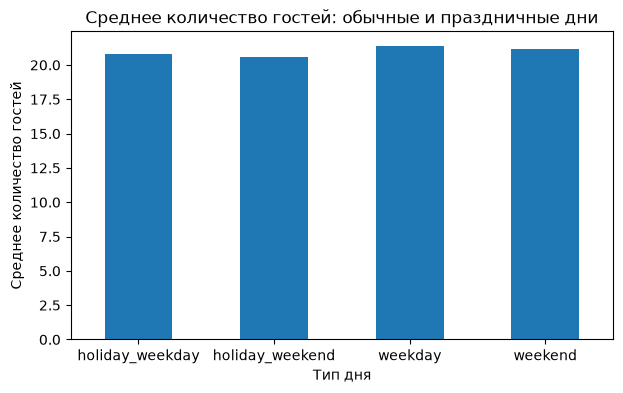

In [23]:
calendar_eda['day_type'] = np.select(
    [
        calendar_eda['is_holiday'].eq(1) & calendar_eda['is_weekend'].eq(1),
        calendar_eda['is_holiday'].eq(1) & calendar_eda['is_weekend'].eq(0),
        calendar_eda['is_holiday'].eq(0) & calendar_eda['is_weekend'].eq(1),
    ],
    ['holiday_weekend', 'holiday_weekday', 'weekend'],
    default='weekday',
)

day_type_stats = calendar_eda.groupby('day_type')['guests'].agg(['count', 'mean', 'median', 'std'])
display(day_type_stats.round(2))

day_type_stats['mean'].plot(kind='bar', figsize=(7, 4), rot=0)
plt.title('Среднее количество гостей: обычные и праздничные дни')
plt.xlabel('Тип дня')
plt.ylabel('Среднее количество гостей')
plt.show()


## Промежуточный вывод

Различие между обычным днем, выходным днем и праздниками не потвердилось. Особенно осторожно следует интерпретировать holiday_weekend: в зависимости от реализации праздничного календаря эта категория содержит всего несколько наблюдений или отсутствует.

Поэтому делать вывод о сильном влиянии конкретного типа дня по имеющейся выборке нельзя. Календарные признаки всё же сохраняются как потенциальные предикторы и будут оцениваться на временной валидации.


# Анализ долгосрочного тренда

Для визуальной оценки долгосрочной динамики используется центрированное 28-дневное скользящее среднее.

center=True используется исключительно для визуализации в EDA. Такой показатель содержит информацию из будущих дат и поэтому не будет использоваться как признак модели.


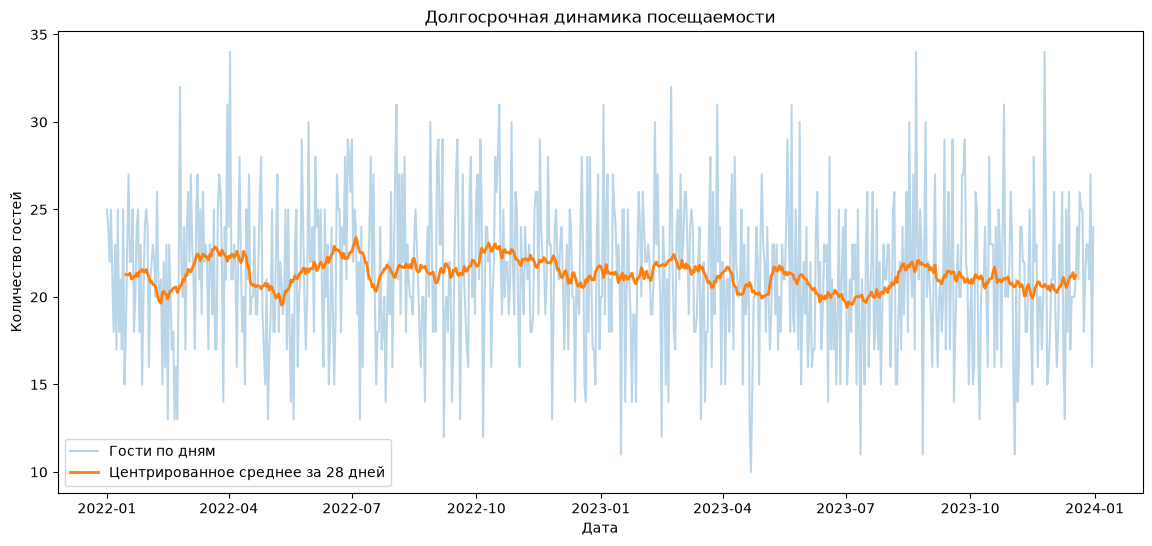

In [24]:
trend_28_eda = daily['guests'].rolling(window=28, center=True).mean()

plt.figure(figsize=(14, 6))
plt.plot(daily['date'], daily['guests'], alpha=0.3, label='Гости по дням')
plt.plot(daily['date'], trend_28_eda, linewidth=2, label='Центрированное среднее за 28 дней')
plt.title('Долгосрочная динамика посещаемости')
plt.xlabel('Дата')
plt.ylabel('Количество гостей')
plt.legend()
plt.show()


Дополнительно агрегируем посещаемость по месяцам и построим линейную линию тренда. Она используется только как описательный инструмент.

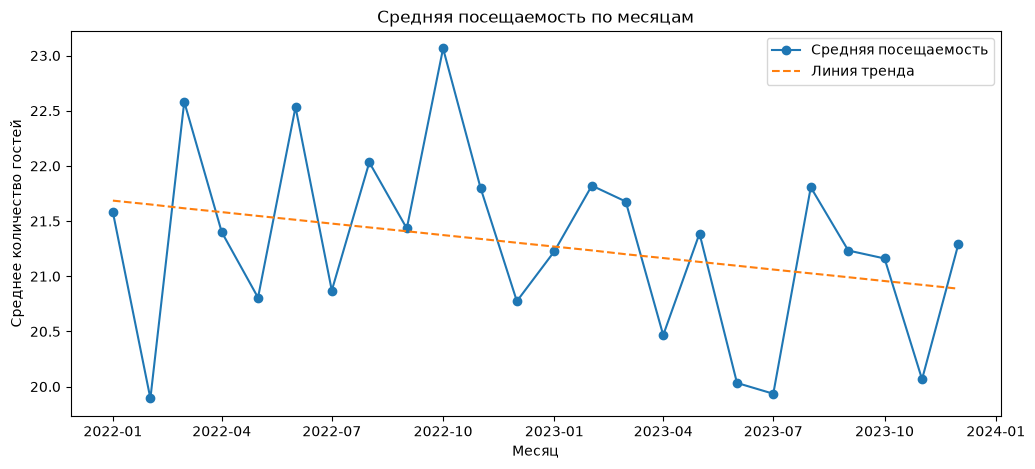

Изменение по линии тренда: -0.035 гостя в месяц


In [25]:
monthly_guests = daily.set_index('date')['guests'].resample('MS').mean()
x = np.arange(len(monthly_guests))
z = np.polyfit(x, monthly_guests.values, 1)
linear_trend = np.polyval(z, x)

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_guests.index,
    monthly_guests.values,
    marker='o',
    label='Средняя посещаемость'
)
plt.plot(
    monthly_guests.index,
    linear_trend,
    linestyle='--',
    label='Линия тренда'
)
plt.title('Средняя посещаемость по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Среднее количество гостей')
plt.legend()
plt.show()

print(f'Изменение по линии тренда: {z[0]:.3f} гостя в месяц')

### Промежуточный вывод

Наклон линейной линии тренда составляет около −0,035 гостя в месяц. Это очень небольшое изменение относительно среднего дневного уровня, поэтому выраженного долгосрочного роста или снижения посещаемости за рассматриваемый период не обнаружено.


# Подготовка признаков для моделирования

На основании EDA формируются календарные признаки, лаги целевой переменной и скользящие статистики.

Все признаки, основанные на guests, рассчитываются только по прошлым значениям. Перед rolling используется shift(1), чтобы значение текущего дня не попадало в признаки и не возникала утечка целевой переменной.

Например, для 10 марта guests_mean_7 содержит информацию максимум по 9 марта.


In [26]:
daily['is_holiday'] = daily['date'].dt.date.map(lambda date: int(date in holiday_dates))
daily['day_of_week'] = daily['date'].dt.dayofweek
daily['month'] = daily['date'].dt.month
daily['is_weekend'] = daily['day_of_week'].isin([5, 6]).astype(int)
daily['days_since_start'] = (daily['date'] - daily['date'].min()).dt.days

for lag in [1, 7, 14, 28]:
    daily[f'guests_lag_{lag}'] = daily['guests'].shift(lag)
for window in [7, 14, 28]:
    daily[f'guests_mean_{window}'] = daily['guests'].shift(1).rolling(window).mean()

model_features = [
    'is_holiday', 'day_of_week', 'month', 'is_weekend', 'days_since_start',
    'guests_lag_1', 'guests_lag_7', 'guests_lag_14', 'guests_lag_28',
    'guests_mean_7', 'guests_mean_14', 'guests_mean_28',
]

display(daily[['date', 'guests', *model_features]].tail(10))

,date,guests,is_holiday,day_of_week,month,is_weekend,days_since_start,guests_lag_1,guests_lag_7,guests_lag_14,guests_lag_28,guests_mean_7,guests_mean_14,guests_mean_28
720,2023-12-22,25,0,4,12,0,720,26.0,20.0,26.0,20.0,21.714286,20.928571,20.928571
721,2023-12-23,25,0,5,12,1,721,25.0,20.0,16.0,34.0,22.428571,20.857143,21.107143
722,2023-12-24,18,0,6,12,1,722,25.0,20.0,13.0,25.0,23.142857,21.500000,20.785714
723,2023-12-25,21,1,0,12,0,723,18.0,21.0,25.0,15.0,22.857143,21.857143,20.535714
724,2023-12-26,23,0,1,12,0,724,21.0,24.0,18.0,16.0,22.857143,21.571429,20.750000
725,2023-12-27,23,0,2,12,0,725,23.0,21.0,26.0,18.0,22.714286,21.928571,21.000000
726,2023-12-28,21,0,3,12,0,726,23.0,26.0,17.0,21.0,23.000000,21.714286,21.178571
727,2023-12-29,27,0,4,12,0,727,21.0,25.0,20.0,21.0,22.285714,22.000000,21.178571
728,2023-12-30,16,0,5,12,1,728,27.0,25.0,20.0,26.0,22.571429,22.500000,21.392857
729,2023-12-31,24,0,6,12,1,729,16.0,18.0,20.0,19.0,21.285714,22.214286,21.035714


В первую модель не включаются orders_lag_1, quantity_lag_1 и revenue_lag_1. При прогнозировании семи будущих дней фактические значения этих показателей для предыдущего прогнозируемого дня ещё неизвестны. Первая модель будет опираться только на календарь и историю guests.


In [27]:
daily = daily[['date', 'guests', *model_features]].dropna().reset_index(drop=True)

print('Размер таблицы для моделирования:', daily.shape)

daily.head()

Размер таблицы для моделирования: (702, 14)


,date,guests,is_holiday,day_of_week,month,is_weekend,days_since_start,guests_lag_1,guests_lag_7,guests_lag_14,guests_lag_28,guests_mean_7,guests_mean_14,guests_mean_28
0,2022-01-29,24,0,5,1,1,28,20.0,20.0,18.0,25.0,20.714286,21.428571,21.285714
1,2022-01-30,25,0,6,1,1,29,24.0,24.0,23.0,24.0,21.285714,21.857143,21.250000
2,2022-01-31,24,0,0,1,0,30,25.0,25.0,27.0,22.0,21.428571,22.000000,21.285714
3,2022-02-01,16,0,1,2,0,31,24.0,18.0,22.0,25.0,21.285714,21.785714,21.357143
4,2022-02-02,21,0,2,2,0,32,16.0,23.0,22.0,21.0,21.000000,21.357143,21.035714


# Итоги EDA

1. Исходные транзакционные данные агрегированы до ежедневной частоты. Целевая переменная guests определяется как количество уникальных customer ID за день и рассматривается как proxy фактической посещаемости.

2. Временной ряд непрерывный: пропущенных календарных дней не обнаружено. Поэтому временные лаги соответствуют реальным календарным интервалам.

3. Пропуски финансовых показателей не приводят к удалению информации о посещениях. Для дней с неполными транзакциями отдельно учитывается качество финансовых агрегатов.

4. Потенциальные выбросы guests, найденные методом IQR, согласуются с изменениями количества заказов, проданных позиций и выручки. Оснований считать их ошибочными наблюдениями не обнаружено, поэтому они сохраняются.

5. Выраженного эффекта выходных и праздников на среднюю посещаемость не обнаружено. Тем не менее календарные признаки сохраняются для последующей проверки на временной валидации.

6. Анализ новых и возвращающихся клиентов оказался неинформативным: в данных всего 100 уникальных customer ID, и уже к концу января 2022 года все они встречаются хотя бы один раз. Поэтому признаки retention не используются.

7. Для моделирования будут использованы календарные признаки, лаги guests и скользящие статистики, рассчитанные исключительно по прошлым наблюдениям.

Следующий этап — построение недельного baseline и сравнение обучаемых моделей с ним на отложенном временном периоде.


Сохораним итоговый дневной датасет для второго ноутбука 02_modelling

In [ ]:
daily.to_csv(
    "../data/processed/daily.csv",
    index=False
)